# Molecular dynamics simulations of a Lennard-Jones-like liquid

In a classical approximation, interactions between atoms consist of a repulsive term due to electron shell overlap and an attractive term due to dipole-dipole interactions. These terms are typically parametrized by the Lennard-Jones potential. For computational convenience, we use the Wang-Frenkel interaction potential between particles $i$ and $j$ instead


$$
U_{ij}^{\mathrm{WF}} =
\begin{cases}
\epsilon \left[ \left( \frac{\sigma}{r_{ij}} \right)^2 - 1 \right]
\left[ \left( \frac{r_c}{r_{ij}} \right)^2 - 1 \right]^2 & \text{if } r_{ij} < r_c \\
0 & \text{otherwise.}
\end{cases}
$$

with $\sigma$ and $\epsilon$ being phenomenological constants and $r_c$ being the cutoff distance. The distance between molecules is denoted $r_{ij}$. We consider a two-dimensional system of spherical molecules with periodic boundary conditions. The molecules all have the same mass $m$.

## 1. Initialization

### (a)

Write a script to generate the positions of a two-dimensional system of molecules with a packing fraction $\phi$, which is defined as

$$
\phi = \frac{N \pi \sigma^2}{A},
$$
with $N$ being the number of molecules and $A$ being the total surface area of
two-dimensional system. Make sure that the molecules do not overlap because
that would lead to very large energies

In [28]:
#1a
import numpy as np
import matplotlib.pyplot as plt 

#Constants
sigma = 1.0
rc = 2.5
epsilon = 1.0
phi = 0.3

#Parameter
N = 100

#function to generate positions with the given tensity -> this variant is very slow 
def generate_positions(N, phi, sigma, factor = 1.0, max_trials=100000):
    positions = []
    cnt = 0

    #calculate A for the chosen N and sigma
    A = (N*np.pi*sigma**2) / phi 

    #quadradic field with sidelenght L
    L = np.sqrt(A)

    #calc minimal distance between two moleculecenters
    min_distance = 2* sigma * factor

    #try as long as their are N molecules or max_tails is reached
    while len(positions) < N and cnt < max_trials:
        p = np.array([np.random.uniform(0, L),
                      np.random.uniform(0, L)])

        # check if their is an overlap
        ok = True
        for q in positions:
            if np.linalg.norm(p - q) < min_distance:
                ok = False
                break

        if ok:
            positions.append(p)

        cnt += 1

    # if the number of paricles cannot be reached within the max 
    # nuber of trails stopp with the error 
    if len(positions) < N:
        raise RuntimeError("density not reachable.")

    return np.array(positions), L


#function to generate positions with the given tensity, vectorized 
def generate_positions_v(N, phi, sigma, factor=1.0, max_trials=100000):
    #create empty arry
    positions = np.empty((2, 0))
    cnt = 0

    # calc A / L  for the chosen density
    A = (N * np.pi * sigma**2) / phi
    L = np.sqrt(A)

    # calc minimal distances between the molecule centers
    min_distance = 2 * sigma * factor

    # create N positions
    while positions.shape[1] < N and cnt < max_trials:
        cnt += 1

        #random guess of new positons
        p = np.array([
            np.random.uniform(0, L),
            np.random.uniform(0, L)
        ])

        # first iteration ?
        if positions.shape[1] == 0:
            positions = np.column_stack((positions, p))
            continue

        # deltas from every existing particel to the new guess
        delta = positions - p[:,np.newaxis]

        # calc distance
        distances = np.sqrt(delta[0, :]**2 + delta[1, :]**2)

        # is the particle in the critical region of another particle? 
        if np.all(distances >= min_distance):
            positions = np.column_stack((positions, p))

    # if N not reached -> error message
    if positions.shape[1] < N:
        raise RuntimeError("density not reachable.")
    
    # transpose 
    positions = positions.T
    return positions, L


#positions, L = generate_positions(N, phi, sigma, 1.0, 1000000)
positions, L = generate_positions_v(N, phi, sigma, 1.0, 1000000)

print("Box length L =", L)
print("Generated positions:")
print(positions)
print(positions.shape)



Box length L = 32.36043187592832
Generated positions:
[[19.59055402 19.36090139]
 [13.18825459 11.16622987]
 [ 2.19316353 10.80979458]
 [ 3.1409337  24.83505439]
 [27.14454835 17.4896918 ]
 [19.97586834  0.76498093]
 [14.38724826 21.19903638]
 [30.21297725 31.11002425]
 [ 0.30913193 22.40834597]
 [ 4.90979036 10.29247123]
 [ 5.38341679 15.57404729]
 [20.86598306  6.39440304]
 [31.3938868  16.40945672]
 [18.95601347 12.45143868]
 [18.6001591  24.36091496]
 [ 3.92991639 19.5379391 ]
 [26.22527072 23.44754983]
 [26.21640789 21.04799949]
 [10.32169784 28.70952782]
 [ 6.78099581  3.62402332]
 [12.35868213 28.82179024]
 [ 0.15956966  8.98513625]
 [21.34920977  8.47593188]
 [10.3631868  19.5427292 ]
 [15.22990937 13.84525391]
 [25.47656973  0.96522074]
 [ 2.16275245 14.2623237 ]
 [ 7.19218384 12.40289815]
 [13.26746664  2.14348475]
 [10.79197022  5.20601435]
 [ 0.16748468 26.652615  ]
 [26.85319589 30.39547249]
 [30.10740253 27.5821126 ]
 [16.95015874  3.14023788]
 [18.38814851 32.35047121]
 

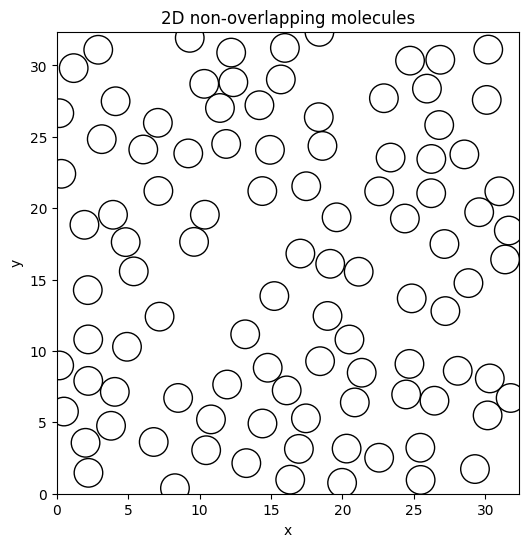

In [29]:
#Testfeld
#plot particles
fig, ax = plt.subplots(figsize=(6, 6))

for x, y in positions:
    circle = plt.Circle((x, y), sigma, fill=False)
    ax.add_patch(circle)

ax.set_xlim(0, L)
ax.set_ylim(0, L)
ax.set_aspect('equal')
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("2D non-overlapping molecules")
plt.show()

(b) Generate initial velocities for all particles by drawing independent velocities
in every dimension from a Gaussian distribution corresponding to an initial
temperature $T$ . Make sure that the velocity of the center of mass of the system
vanishes.

In [30]:
#1b
# function to generate the velocities
def generate_velocities(N, T, k_B, m):
    # for corresbondig to a Temp use a sigma_v(T)
    # Äquipartitionstheorem 1/2 kb T per dimension
    sigma_v = np.sqrt(k_B*T/m)
    # create velocities
    v = np.random.normal(0.0, sigma_v, size=(N, 2))
    # subtract center-of-mass velocity
    v_cm = np.mean(v, axis=0)
    v_cm_corr = v - v_cm

    return v, v_cm_corr 

# check the function (vanishes v of des center of mass)
N = 100
m =1.0
k_B = 1.0
T = 1.0

v, v_cm_corr = generate_velocities(N, T, k_B, m)
print("Number of Values", np.shape(v))
print("Means of  direction (without COM correction):", np.mean(v, axis=0))
print("Means of  direction (with COM correction):", np.mean(v_cm_corr, axis=0))
#print(positions)


Number of Values (100, 2)
Means of  direction (without COM correction): [ 0.00179928 -0.1846755 ]
Means of  direction (with COM correction): [ 2.77555756e-19 -2.33146835e-17]


2 Force calculation
The force between the molecules is given as usual by $f_{ij} = −\nabla U^{WF}_{ij}$ . The forces
are assumed to be pairwise additive.

    (a) Write a script to calculate the force on all particles from the positions of the particles. Take care that periodic boundary conditions are used.


In [31]:
#2a
@njit
def pair_force(vec_rij, epsilon, sigma, rc):
    # absolutvalue of the vector rij
    r = np.sqrt(np.dot(vec_rij,vec_rij))

    # chec if inside the cutoff distance (avoid division 0 )
    if r >= rc or r < 1e-48:
        return np.zeros(2)
    
    # calculate a force
    A = (sigma**2 / r**2) -1.0
    B = (rc**2 / r**2) -1.0
    
    f = vec_rij * (2*epsilon/r**4) * (sigma**2 * B**2 + 2 * A * B * rc**2)
    return f

# test the function
#rc = 10
#i = 0
#j = 6
#rij = positions[i]-positions[j]
#r = np.linalg.norm(rij)
#f = pair_force(rij, epsilon, sigma, rc)
#print(rij)
#print(r)
#print(f)
#print(positions)

# calculate total forces
def total_forces(positions, L, epsilon, sigma, rc):
    N = len(positions)
    forces = np.zeros_like(positions)
    U_tot = 0
    # seite 79 im scirpt!
    for i in range(N - 1):
        for j in range(i + 1, N):
            rij = positions[i] - positions[j]
            # this is to have periodic poundary conditions
            rij -= L * np.round(rij / L)
            fij  = pair_force(rij, epsilon, sigma, rc)
            # add force to i
            forces[i] += fij
            # same force accts with opposite sign to j
            forces[j] -= fij

    return forces

# Test of te funciton
rc = 1.5
f_tot = total_forces(positions, L, epsilon, sigma, rc)
idx = np.where(np.linalg.norm(f_tot, axis=1) != 0)[0]
print(L)
print(f_tot[idx])


32.36043187592832
[[ 0.32449948 -0.25557273]
 [ 0.1066188  -0.09439976]
 [-0.1066188   0.09439976]
 [-0.32449948  0.25557273]]


        (b) Include a calculation of the total potential energy of the system in the calculation
of the forces

In [32]:
#2b
@njit
def pair_force_potential_Energy(vec_rij, epsilon, sigma, rc):
    # absolutvalue of the vector rij
    r = np.sqrt(np.dot(vec_rij,vec_rij))

    # chec if inside the cutoff distance (avoid division 0 )
    if r >= rc or r < 1e-48:
       return np.zeros(2), 0.0
    
    # calculate a force
    A = (sigma**2 / r**2) -1.0
    B = (rc**2 / r**2) -1.0
    f = vec_rij * (2*epsilon/r**4) * (sigma**2 * B**2 + 2 * A * B * rc**2)

    # calc E Pot
    U = epsilon*A*B**2
    return f, U

# sum up forces and energys 
@njit
def total_forces_Energy(positions, L, epsilon, sigma, rc):
    N = len(positions)
    forces = np.zeros_like(positions)
    U_tot = 0
    # seite 79 im scirpt!
    for i in range(N - 1):
        for j in range(i + 1, N):
            rij = positions[i] - positions[j]
            # this is to have periodic poundary conditions
            rij -= L * np.round(rij / L)
            fij, Uij  = pair_force_potential_Energy(rij, epsilon, sigma, rc)
            # add force to i
            forces[i] += fij
            # same force accts with opposite sign to j
            forces[j] -= fij
            # summ up potential Energy
            U_tot += Uij
    return forces, U_tot

# Test of te funciton
rc = 2.5
f_tot, U_tot = total_forces_Energy(positions, L, epsilon, sigma, rc)
idx = np.where(np.linalg.norm(f_tot, axis=1) != 0)[0]
print(L)
print(f_tot[idx])
print(U_tot)


32.36043187592832
[[-2.43445740e+00 -1.09407687e+00]
 [-7.34359146e-01 -5.35121428e-01]
 [-1.96345657e-01  7.12828246e-01]
 [ 1.60549854e-01  6.91578406e-01]
 [ 1.33990100e-01  1.04379451e+00]
 [ 2.68448338e-01 -2.88573688e-01]
 [-1.39983244e-01  1.09689926e+00]
 [-3.79732168e-01 -9.79774943e-01]
 [ 2.42515881e-01 -2.58186875e-02]
 [ 4.68051946e-04  1.26721860e-01]
 [ 1.69459720e+00 -9.15663683e-01]
 [-1.57294108e+00 -1.89729557e-01]
 [ 6.12971340e-02 -3.20626919e-01]
 [-1.68897722e-01 -6.68953628e-01]
 [-3.81268252e-01 -9.58838179e-01]
 [-3.48999533e-03  3.86053630e-01]
 [-8.73607610e-02 -5.58932097e-01]
 [-9.61599712e-01 -4.40646713e-01]
 [ 5.30254212e-03  1.15587988e-01]
 [ 2.13478117e+00  1.34669543e+00]
 [-1.28476630e-01  1.94482900e+00]
 [ 3.51449889e-01  6.42733650e-01]
 [-1.71417915e-01  4.82112503e-02]
 [ 2.88747763e-02  6.91235478e-01]
 [-3.51449889e-01 -6.42733650e-01]
 [-1.94035344e-01 -1.00671474e+00]
 [-2.12360342e-01 -3.91644156e-01]
 [ 1.14628805e+00  4.21690254e-01]
 [

(c) Evaluate the scaling of computational cost of the force calculation with the num-
ber of particles $N$ .

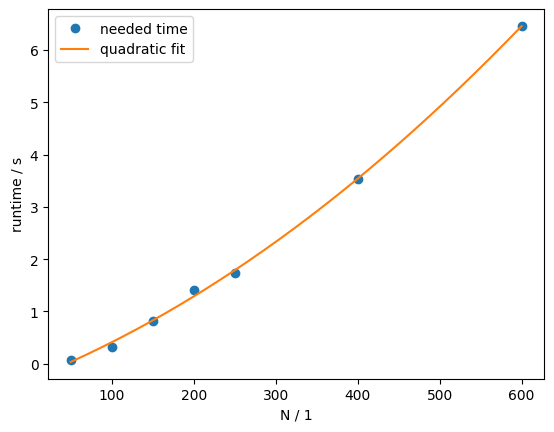

Fit: t(N) = a*N^2 + b*N + c
a = 8.328379215063533e-06
b = 0.00626677345606613
c = -0.29904631885997823


In [33]:
#2c
import time
N_values = [50,100,150,200,250,400,600] 
times = []
repeats = 2 # per N_value

for N in N_values:
    positions, L = generate_positions_v(N, phi, sigma, 1.0, 1000000)
    # list for times with same N to calc mean
    t_list =[]
    # do this for the number of repeats
    for _ in range(repeats):
        t0 = time.perf_counter()
        f  = total_forces(positions, L, epsilon, sigma, rc)
        t1 = time.perf_counter()
        t_list.append(t1-t0)
    # calc mean of all times for same n
    times.append(np.mean(t_list)) 

# crate a fit to show its quatratic 
times = np.array(times)
N_values_plot = np.array(N_values)
coeff = np.polyfit(N_values_plot, times, 2)
a, b, c = coeff
N_fit = np.linspace(N_values_plot.min(), N_values_plot.max(), 300)
t_fit = a * N_fit**2 + b * N_fit + c

plt.plot(N_values_plot, times, 'o', label='needed time')
plt.plot(N_fit, t_fit, '-', label='quadratic fit')
plt.xlabel('N / 1')
plt.ylabel('runtime / s')
plt.legend()
plt.show()

print("Fit: t(N) = a*N^2 + b*N + c")
print("a =", a)
print("b =", b)
print("c =", c)


3 Integration of the equations of motion

(a)

Nondimensionalize the equations and pick a sensible time step in terms of $\sigma$, $\epsilon$ and the particle mass $m$.

The velocity-Verlet algorithm for positions $r$, velocities $v$ and forces $f$ consists of the following steps:

$$
v\left(t + \frac{\Delta t}{2}\right) = v(t) + \frac{f(t)}{2m}\Delta t
$$

$$
r(t + \Delta t) = r(t) + v\left(t + \frac{\Delta t}{2}\right)\Delta t
$$

$$
f(t + \Delta t) = f(r(t + \Delta t))
$$

$$
v(t + \Delta t) = v\left(t + \frac{\Delta t}{2}\right) + \frac{f(t+\Delta t)}{2m}\Delta t
$$


In [34]:
#3a
# no code required

Die Antwort sind mehr oder weniger nur Formeln

(b)

Implement the velocity-Verlet algorithm to solve the equations of motion.

In [35]:
#3b
def velocity_verlet(pos, vel, L, n_steps, dt, epsilon, sigma, rc, m):
    # use N of pos
    N = len(pos)

    # calculate forces and Potential energy
    forces, U = total_forces_Energy(pos, L, epsilon=epsilon, sigma=sigma, rc=rc)

    # initalize arrays for energys
    E_kin_hist = np.zeros(n_steps)
    E_pot_hist = np.zeros(n_steps)
    E_tot_hist = np.zeros(n_steps)
    T_hist = np.zeros(n_steps)
    pos_hist = np.zeros((n_steps, N, 2))


    for i in range(n_steps):
        # calc fist velocity halfstep
        vel_half = vel + 0.5 * forces / m * dt

        # Full-step position
        pos = pos + vel_half * dt

        # Pos Modulo L is used for periodic boundary conditions
        pos = pos % L

        # New forces forces after step
        forces_new, U = total_forces_Energy(pos, L, epsilon=epsilon, sigma=sigma, rc=rc)

        # Full-step velocity
        vel = vel_half + 0.5 * forces_new / m * dt

        # Update forces
        forces = forces_new

        # calc kinetic enerty
        E_kin = 0.5 * m * np.sum(vel**2)

        # Temperature in 2D
        # degrees of freedom = 2N - 2
        dof = 2 * N - 2
        T = 2 * E_kin / dof

        E_kin_hist[i] = E_kin
        E_pot_hist[i] = U
        E_tot_hist[i] = E_kin + U
        T_hist[i] = T

        pos_hist[i] = pos
        print(i, "/",n_steps)
    return pos, vel, pos_hist, E_kin_hist, E_pot_hist, E_tot_hist, T_hist

(c)

Calculate the kinetic energy at every integer time step and plot the total energy and the temperature as a function of time.

0 / 1000
1 / 1000
2 / 1000
3 / 1000
4 / 1000
5 / 1000
6 / 1000
7 / 1000
8 / 1000
9 / 1000
10 / 1000
11 / 1000
12 / 1000
13 / 1000
14 / 1000
15 / 1000
16 / 1000
17 / 1000
18 / 1000
19 / 1000
20 / 1000
21 / 1000
22 / 1000
23 / 1000
24 / 1000
25 / 1000
26 / 1000
27 / 1000
28 / 1000
29 / 1000
30 / 1000
31 / 1000
32 / 1000
33 / 1000
34 / 1000
35 / 1000
36 / 1000
37 / 1000
38 / 1000
39 / 1000
40 / 1000
41 / 1000
42 / 1000
43 / 1000
44 / 1000
45 / 1000
46 / 1000
47 / 1000
48 / 1000
49 / 1000
50 / 1000
51 / 1000
52 / 1000
53 / 1000
54 / 1000
55 / 1000
56 / 1000
57 / 1000
58 / 1000
59 / 1000
60 / 1000
61 / 1000
62 / 1000
63 / 1000
64 / 1000
65 / 1000
66 / 1000
67 / 1000
68 / 1000
69 / 1000
70 / 1000
71 / 1000
72 / 1000
73 / 1000
74 / 1000
75 / 1000
76 / 1000
77 / 1000
78 / 1000
79 / 1000
80 / 1000
81 / 1000
82 / 1000
83 / 1000
84 / 1000
85 / 1000
86 / 1000
87 / 1000
88 / 1000
89 / 1000
90 / 1000
91 / 1000
92 / 1000
93 / 1000
94 / 1000
95 / 1000
96 / 1000
97 / 1000
98 / 1000
99 / 1000
100 / 1000

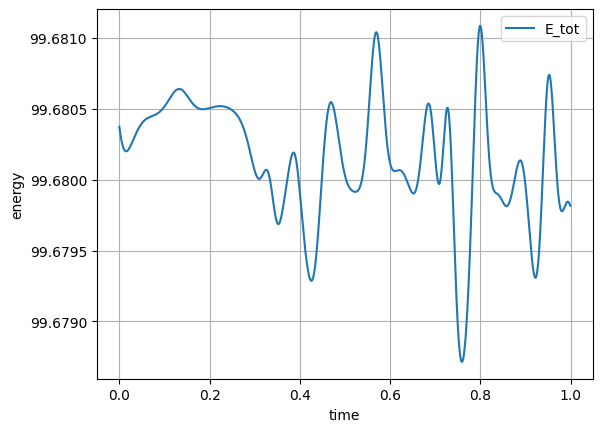

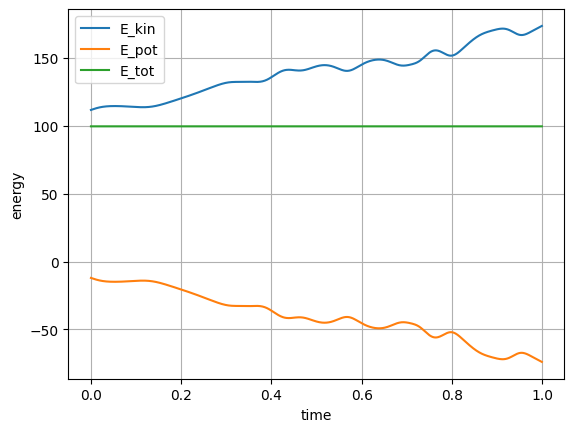

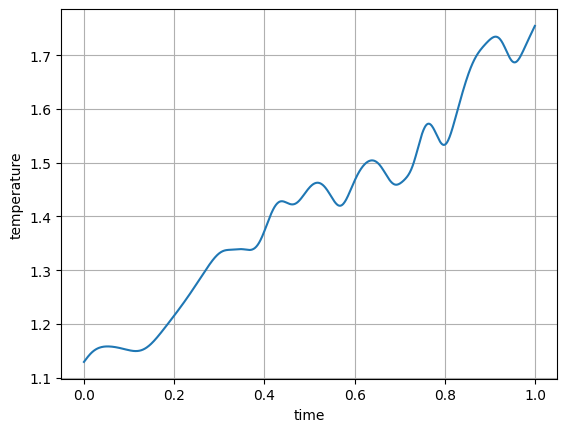

In [36]:
#3c
# Example parameters
N = 100
sigma = 1.0
epsilon = 1.0
m = 1.0
rc = 2.5
phi = 0.3
dt = 0.001
n_steps = 1000

positions, L = generate_positions_v(N, phi, sigma, 1.0, 1000000)
_, v = generate_velocities(N, 1, 1, m)

pos, vel, pos_hist, E_kin_hist, E_pot_hist, E_tot_hist, T_hist = velocity_verlet(
    positions,v, L,
    n_steps=n_steps,
    dt=dt,
    epsilon=epsilon,
    sigma=sigma,
    rc=rc,
    m=m
)

time = np.arange(n_steps) * dt

plt.figure()
plt.plot(time, E_tot_hist, label="E_tot")
plt.xlabel("time")
plt.ylabel("energy")
plt.legend()
plt.grid()
plt.show()

plt.figure()
plt.plot(time, E_kin_hist, label="E_kin")
plt.plot(time, E_pot_hist, label="E_pot")
plt.plot(time, E_tot_hist, label="E_tot")
plt.xlabel("time")
plt.ylabel("energy")
plt.legend()
plt.grid()
plt.show()

plt.figure()
plt.plot(time, T_hist)
plt.xlabel("time")
plt.ylabel("temperature")
plt.grid()
plt.show()

# Computer Simulations  
## 4th problem set
# Molecular dynamics simulations in the canonical ensemble

In the canonical ensemble, the temperature $T$ is kept constant in the thermodynamic limit. In a finite-sized system, that means that the temperature will fluctuate around $T$ with a well-defined variance. One way to set the temperature in the canonical ensemble is using the Heyes thermostat, which works as follows.

During the simulation, we will occasionally attempt to rescale all velocities by a factor $z$, with $-\ln z$ being evenly distributed in an interval between $-\Delta$ and $\Delta$. After rescaling, the total kinetic energy has increased or decreased by a factor $z^2$.

The distribution of the total kinetic energy $E_k$ in $d$ dimensions should follow
$$
P(E_k) =
C
\left(\sqrt{E_k}\right)^{d(N-1)}
\exp\left(
-\frac{E_k}{k_B T}
\right).
$$

To attain this distribution in the simulation, we accept the rescaling move with a probability

$$
p_{\mathrm{acc}}(E_k \to z^2 E_k)
=
\min\left(
1,
z^{d(N-1)}
\exp\left(
-\frac{E_k(z^2 - 1)}{k_B T}
\right)
\right).
$$

---

# 1. Thermostat

## (a)

Implement the Heyes thermostat for the Lennard-Jones-like simulation system from the 3rd problem sheet. Take care that the algorithm is still time reversible by putting the rescaling between the two half-step updates of the velocity $\mathbf{v}$ in the velocity Verlet algorithm.

Pick $\Delta$ relatively small, in order to disturb the dynamics as little as possible. It is not necessary, but also not wrong, to apply the thermostat every time step.


0 / 5000
100 / 5000
200 / 5000
300 / 5000
400 / 5000
500 / 5000
600 / 5000
700 / 5000
800 / 5000
900 / 5000
1000 / 5000
1100 / 5000
1200 / 5000
1300 / 5000
1400 / 5000
1500 / 5000
1600 / 5000
1700 / 5000
1800 / 5000
1900 / 5000
2000 / 5000
2100 / 5000
2200 / 5000
2300 / 5000
2400 / 5000
2500 / 5000
2600 / 5000
2700 / 5000
2800 / 5000
2900 / 5000
3000 / 5000
3100 / 5000
3200 / 5000
3300 / 5000
3400 / 5000
3500 / 5000
3600 / 5000
3700 / 5000
3800 / 5000
3900 / 5000
4000 / 5000
4100 / 5000
4200 / 5000
4300 / 5000
4400 / 5000
4500 / 5000
4600 / 5000
4700 / 5000
4800 / 5000
4900 / 5000
T_set = 0.8
mean T after equilibration = 0.8022700815058176
std T after equilibration  = 0.0809482155662507
acceptance rate = 0.8092

0 / 5000
100 / 5000
200 / 5000
300 / 5000
400 / 5000
500 / 5000
600 / 5000
700 / 5000
800 / 5000
900 / 5000
1000 / 5000
1100 / 5000
1200 / 5000
1300 / 5000
1400 / 5000
1500 / 5000
1600 / 5000
1700 / 5000
1800 / 5000
1900 / 5000
2000 / 5000
2100 / 5000
2200 / 5000
2300 / 5000
24

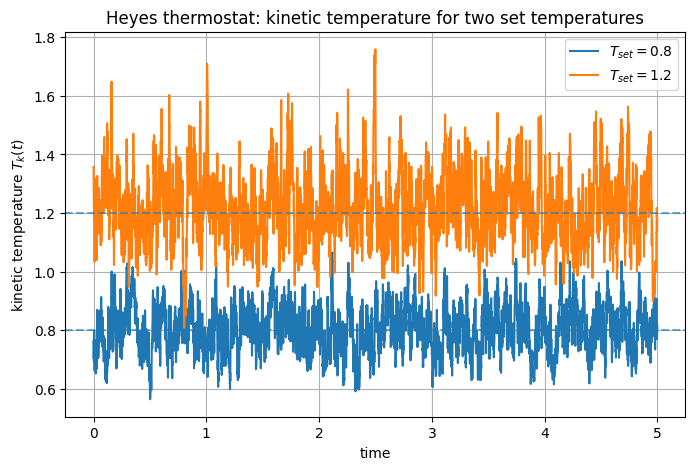

In [38]:
from numba import njit
# 1a
def heyes_thermostat(v, set_T, Delta, m=1.0, kb=1.0):
    # get N and d from the shape of v
    N, d = v.shape

    # current kinetic energy
    E_k = 0.5 * m * np.sum(v**2)

    # get z, where -ln(z) is uniformly distributed in [-Delta, Delta]
    x = np.random.uniform(-Delta, Delta)
    z = np.exp(-x)

    # acceptance probability as given in the exercise
    p_acc = z**(d * (N - 1)) * np.exp(-E_k * (z**2 - 1.0) / (kb * set_T))
    p_acc = min(1.0, p_acc)

    # accept or reject
    if np.random.rand() < p_acc:
        return z * v, True
    else:
        return v, False
    

# now put this function in the velocity verlet from 3. exercice
def velocity_verlet_with_heyes(pos, vel, L, n_steps, dt, epsilon, sigma, rc, m, set_T, Delta):
    # use N from pos
    N = len(pos)
    d = 2
    kb = 1.0

    # calculate initial forces and potential energy
    forces, U = total_forces_Energy(pos, L, epsilon=epsilon, sigma=sigma, rc=rc)

    # initialize arrays for energies and temperature
    E_kin_hist = np.zeros(n_steps)
    E_pot_hist = np.zeros(n_steps)
    E_tot_hist = np.zeros(n_steps)
    T_hist = np.zeros(n_steps)
    pos_hist = np.zeros((n_steps, N, 2))
    accepted_hist = np.zeros(n_steps, dtype=bool)

    for i in range(n_steps):
        # first velocity half-step
        vel_half = vel + 0.5 * forces / m * dt

        # Heyes thermostat after first half-step
        vel_half, accepted = heyes_thermostat(
            vel_half,
            set_T=set_T,
            Delta=Delta,
            m=m,
            kb=kb
        )

        # full-step position
        pos = pos + vel_half * dt

        # periodic boundary conditions
        pos = pos % L

        # new forces after position update
        forces_new, U = total_forces_Energy(
            pos,
            L,
            epsilon=epsilon,
            sigma=sigma,
            rc=rc
        )

        # second velocity half-step
        vel = vel_half + 0.5 * forces_new / m * dt

        # update forces
        forces = forces_new

        # kinetic energy
        E_kin = 0.5 * m * np.sum(vel**2)

        # kinetic temperature according to the exercise
        dof = d * N - d - 1
        T = 2 * E_kin / (kb * dof)

        E_kin_hist[i] = E_kin
        E_pot_hist[i] = U
        E_tot_hist[i] = E_kin + U
        T_hist[i] = T
        pos_hist[i] = pos
        accepted_hist[i] = accepted

        # optional: not every step, otherwise it is slow
        if i % 100 == 0:
            print(i, "/", n_steps)

    return pos, vel, pos_hist, E_kin_hist, E_pot_hist, E_tot_hist, T_hist, accepted_hist




# Parameters
N = 100
sigma = 1.0
epsilon = 1.0
m = 1.0
rc = 2.5
phi = 0.3
dt = 0.001
n_steps = 5000

Delta = 0.05

# Two set temperatures required in 1b
T_values = [0.8, 1.2]

time = np.arange(n_steps) * dt

plt.figure(figsize=(8, 5))

for set_T in T_values:
    # Generate new initial configuration for each temperature
    positions, L = generate_positions_v(N, phi, sigma, 1.0, 1000000)
    _, v = generate_velocities(N, set_T, 1, m)

    pos, vel, pos_hist, E_kin_hist, E_pot_hist, E_tot_hist, T_hist, accepted_hist = velocity_verlet_with_heyes(
        positions,
        v,
        L,
        n_steps=n_steps,
        dt=dt,
        epsilon=epsilon,
        sigma=sigma,
        rc=rc,
        m=m,
        set_T=set_T,
        Delta=Delta
    )

    # Plot kinetic temperature
    plt.plot(time, T_hist, label=fr"$T_{{set}} = {set_T}$")

    # Print simple diagnostics after equilibration
    start = int(0.2 * n_steps)
    print("T_set =", set_T)
    print("mean T after equilibration =", np.mean(T_hist[start:]))
    print("std T after equilibration  =", np.std(T_hist[start:]))
    print("acceptance rate =", np.mean(accepted_hist))
    print()

# Add horizontal reference lines for the two set temperatures
for set_T in T_values:
    plt.axhline(set_T, linestyle="--", alpha=0.6)

plt.xlabel("time")
plt.ylabel(r"kinetic temperature $T_k(t)$")
plt.title("Heyes thermostat: kinetic temperature for two set temperatures")
plt.legend()
plt.grid()
plt.show()